In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/plant_project/archive.zip'
extract_path = '/content/plant_data'

print("Розархівовуємо...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Готово! Вміст папки:")
for item in os.listdir(extract_path):
    print(item)

Розархівовуємо...
Готово! Вміст папки:
plantvillage dataset


In [3]:
import os

data_dir = '/content/plant_data/plantvillage dataset'

folders = os.listdir(data_dir)
print(f"Кількість класів: {len(folders)}")
print("\nПерші 5 класів:")
for f in folders[:5]:
    print(f)

Кількість класів: 3

Перші 5 класів:
color
segmented
grayscale


In [4]:
data_dir = '/content/plant_data/plantvillage dataset/color'

folders = os.listdir(data_dir)
print(f"Кількість класів: {len(folders)}")
print("\nПерші 5 класів:")
for f in folders[:5]:
    print(f)

Кількість класів: 38

Перші 5 класів:
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Squash___Powdery_mildew
Apple___healthy
Pepper,_bell___healthy
Tomato___Tomato_mosaic_virus


In [5]:
import torch
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

data_dir = '/content/plant_data/plantvillage dataset/color'

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(data_dir, transform=train_transforms)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f'Класів: {num_classes}')
print(f'Всього фото: {len(full_dataset)}')

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transforms

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print('Дані готові!')

Класів: 38
Всього фото: 54305
Дані готові!


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Використовується: {device}')

model = models.mobilenet_v2(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(model.last_channel, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

print('Модель готова!')

Використовується: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 13.6M/13.6M [00:00<00:00, 62.1MB/s]


Модель готова!


In [7]:
num_epochs = 10
train_losses, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    train_losses.append(running_loss / len(train_loader))
    val_accuracies.append(acc)
    print(f'Епоха {epoch+1}/{num_epochs} | Loss: {running_loss/len(train_loader):.4f} | Точність: {acc:.2f}%')

print('Навчання завершено!')

Епоха 1/10 | Loss: 0.4203 | Точність: 95.93%
Епоха 2/10 | Loss: 0.1712 | Точність: 96.25%
Епоха 3/10 | Loss: 0.1424 | Точність: 97.09%
Епоха 4/10 | Loss: 0.1325 | Точність: 96.86%
Епоха 5/10 | Loss: 0.1264 | Точність: 96.94%
Епоха 6/10 | Loss: 0.1232 | Точність: 96.79%
Епоха 7/10 | Loss: 0.1177 | Точність: 96.91%
Епоха 8/10 | Loss: 0.1149 | Точність: 97.06%
Епоха 9/10 | Loss: 0.1095 | Точність: 97.12%
Епоха 10/10 | Loss: 0.1070 | Точність: 97.04%
Навчання завершено!


In [8]:
import json

save_dir = '/content/drive/MyDrive/plant_project'

torch.save(model.state_dict(), f'{save_dir}/plant_model.pth')

with open(f'{save_dir}/class_names.json', 'w') as f:
    json.dump(class_names, f)

print('Модель збережена!')
print(f'Файли у: {save_dir}')

Модель збережена!
Файли у: /content/drive/MyDrive/plant_project


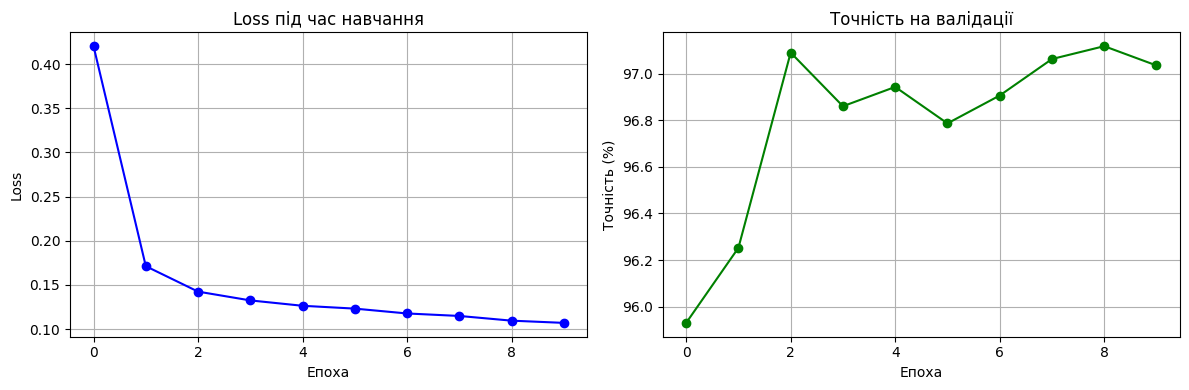

Графіки збережені!


In [9]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, 'b-o')
ax1.set_title('Loss під час навчання')
ax1.set_xlabel('Епоха')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(val_accuracies, 'g-o')
ax2.set_title('Точність на валідації')
ax2.set_xlabel('Епоха')
ax2.set_ylabel('Точність (%)')
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{save_dir}/training_results.png')
plt.show()
print('Графіки збережені!')